In [13]:
from typing import TypedDict, Optional

class AssistantState(TypedDict):
    message: str
    intent: str
    risk: str
    plan: str
    draft: str
    decision: str
    critic_count: int
    critique: Optional[str]   # detailed feedback from critic
    final_answer: str

In [14]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="deepseek/deepseek-v3.2",
    temperature=0.2,
    api_key='your_key_here',
    base_url="https://openrouter.ai/api/v1"
)

In [15]:
def detect_intent_and_risk(state: AssistantState):
    # Initialize counter and critique for self‑criticism loop
    state.setdefault('critic_count', 0)
    state.setdefault('critique', "")

    prompt = f"""
پیام کاربر:
{state["message"]}

۱. هدف پیام را مشخص کن
۲. سطح حساسیت را فقط با یکی از این کلمات تعیین کن:
low
medium
high

خروجی را دقیقاً در این قالب بده:
intent: ...
risk: ...
"""
    result = llm.invoke(prompt).content
    lines = result.splitlines()
    state["intent"] = lines[0].replace("intent:", "").strip()
    state["risk"] = lines[1].replace("risk:", "").strip()
    return state

In [16]:
def planner(state: AssistantState):
    prompt = f"""
کاربر فارسی زبان است.
بر اساس هدف زیر یک برنامه کوتاه برای پاسخ بنویس:

هدف:
{state["intent"]}

سطح حساسیت:
{state["risk"]}
"""
    state["plan"] = llm.invoke(prompt).content
    return state

In [17]:
def responder(state: AssistantState):
    prompt = f"""
بر اساس این برنامه پاسخ اولیه تولید کن:

برنامه:
{state["plan"]}

پیام کاربر:
{state["message"]}
"""
    state["draft"] = llm.invoke(prompt).content
    return state

In [18]:
import json

def critic(state: AssistantState):
    prompt = f"""
شما یک کارشناس تضمین کیفیت هستید. لطفاً پاسخ پیش‌نویس زیر را ارزیابی کنید:

پیش‌نویس:
{state["draft"]}

نقد خود را به صورت **JSON معتبر** با فیلدهای زیر بنویسید:
- "score": عددی از ۰ تا ۱۰ (۱۰ یعنی عالی)
- "issues": لیستی از مشکلات خاص (مثلاً ["توضیح نامفهوم"، "نقص در نکات حقوقی"])
- "suggestions": یک پاراگراف مختصر درباره چگونگی بهبود پاسخ

سطح حساسیت سؤال اصلی: {state["risk"]}
هرچه سطح حساسیت بالاتر باشد، ارزیابی شما باید سخت‌گیرانه‌تر باشد.

فقط خود شیء JSON را خروجی دهید (بدون توضیح اضافی).
"""
    response = llm.invoke(prompt).content
    try:
        critique = json.loads(response)
    except:
        critique = {"score": 5, "issues": ["نقد نامعتبر"], "suggestions": "لطفاً بازنویسی کنید."}

    state["critique"] = response  # ذخیره نقد خام برای استفاده در بهبود

    # تعیین آستانه بر اساس سطح حساسیت
    risk_threshold = {"low": 6, "medium": 8, "high": 9}
    threshold = risk_threshold.get(state["risk"], 7)

    score = critique.get("score", 0)
    state["critic_count"] += 1

    # تأیید اگر نمره >= آستانه یا تکرار بیش از حد مجاز
    if score >= threshold or state["critic_count"] >= 5:
        state["decision"] = "approve"
    else:
        state["decision"] = "revise"

    return state


In [19]:
def improve(state: AssistantState):
    prompt = f"""
شما یک ویراستار حرفه‌ای هستید. لطفاً پیش‌نویس زیر را بر اساس نقد ارائه‌شده بهبود دهید.

پیش‌نویس:
{state["draft"]}

نقد:
{state["critique"]}

پاسخ را بازنویسی کنید تا تمام مشکلات مطرح‌شده برطرف شوند. پاسخ جدید باید:
- دقیق‌تر و کامل‌تر باشد
- لحن حرفه‌ای‌تری داشته باشد
- از نظر حقوقی و امنیتی ایمن‌تر باشد (در صورت لزوم)

فقط متن بهبودیافته را خروجی دهید.
"""
    state["draft"] = llm.invoke(prompt).content
    return state

In [20]:
def finalize(state: AssistantState):
    state["final_answer"] = state["draft"]
    return state

In [21]:
from langgraph.graph import StateGraph, END

graph = StateGraph(AssistantState)

graph.add_node("detector", detect_intent_and_risk)
graph.add_node("planner", planner)
graph.add_node("responder", responder)
graph.add_node("critic", critic)
graph.add_node("improve", improve)
graph.add_node("finalize", finalize)

graph.set_entry_point("detector")

graph.add_edge("detector", "planner")
graph.add_edge("planner", "responder")
graph.add_edge("responder", "critic")

def review_route(state: AssistantState):
    if state["decision"] == "revise":
        return "improve"
    return "finalize"

graph.add_conditional_edges(
    "critic",
    review_route,
    {
        "improve": "improve",
        "finalize": "finalize"
    }
)

graph.add_edge("improve", "critic")
graph.add_edge("finalize", END)

app = graph.compile()

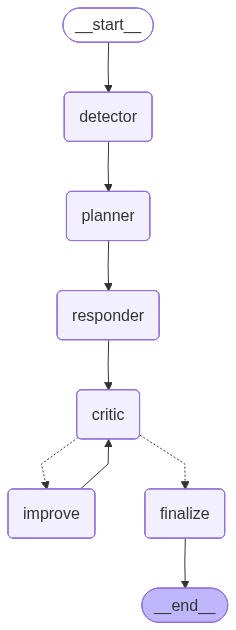

In [22]:
app

In [23]:
result = app.invoke(
    {
        "message": "می‌خوام بدونم آیا بستن قرارداد بدون وکیل خطرناک است؟"
    }
)

print(result["final_answer"])

**تذکر ضروری**
این متن صرفاً حاوی اطلاعات عمومی و نمونه‌هایی از ملاحظات رایج است و به هیچ وجه جایگزین مشاوره حقوقی تخصصی نمی‌شود. پیش از هر اقدامی، حتماً با یک وکیل متخصص در حوزه مرتبط با قرارداد خود مشورت نمایید.

**نمونه‌ای از خطرات کلیدی انعقاد قرارداد بدون مشاوره حقوقی**
خطرات بالقوه می‌تواند بسته به ماهیت قرارداد (مانند تجاری، کاری، مشارکتی، اجاره و...) بسیار متنوع باشد. برخی از این خطرات شامل موارد زیر است:
۱.  **ابهام و تفسیر نادرست مفاد**: عبارات کلیدی مبهم در مورد «حوزه قرارداد»، «تعهدات اصلی»، «قوه قاهره» یا «تحویل» می‌تواند به سوءتفاهم‌های پرهزینه و اختلافات آتی منجر شود.
۲.  **شروط ناقص، نامتوازن یا مغایر با قانون**: ممکن است شروط ضروری مانند «حق فسخ»، «شیوه حل و فصل اختلافات» (حکمیت یا دادگاه)، «ضمانت اجرای تخلف» یا حتی مواردی که طبق قانون آمره باطل هستند، به درستی یا به نفع شما تنظیم نشده باشد.
۳.  **تعهدات و بار مالی پنهان یا غیرمنصفانه**: هزینه‌ها، جریمه‌ها، مالیات‌های تکلیفی یا سازوکار تعدیل قیمت ممکن است به وضوح پیش‌بینی نشده یا به شکلی یک‌طرفه تنظیم شده باشند.
۴.  **

In [24]:
result

{'message': 'می\u200cخوام بدونم آیا بستن قرارداد بدون وکیل خطرناک است؟',
 'intent': 'درخواست ارزیابی خطرات حقوقی بستن قرارداد بدون وکیل',
 'risk': 'high',
 'plan': 'برنامه پاسخ به درخواست ارزیابی خطرات حقوقی بستن قرارداد بدون وکیل:\n\n1. **هشدار فوری و صریح**  \n   - تأکید بر اینکه این پاسخ مشاوره حقوقی نیست و فقط اطلاعات عمومی ارائه می\u200cدهد.  \n   - توصیه اکید به مراجعه فوری به وکیل متخصص قبل از هر اقدامی.\n\n2. **فهرست خطرات کلیدی**  \n   - تفسیر نادرست مفاد قرارداد (ابهام در تعهدات، جریمه\u200cها، فورس ماژور).  \n   - نقاط ضعف در شروط حفظ منافع (حق فسخ، حل اختلاف، ضمانت اجرا).  \n   - ریسک\u200cهای مالی پنهان (مالیات، جریمه تأخیر، خسارت تأخیر تأدیه).  \n   - عدم پیش\u200cبینی شرایط اضطراری (تعلیق قرارداد، تغییر قوانین).\n\n3. **پیامدهای محتمل**  \n   - دعاوی حقوقی پرهزینه و طولانی مدت.  \n   - از دست دادن حقوق قانونی یا امتیازات قراردادی.  \n   - آسیب به اعتبار تجاری و رابطه با طرف مقابل.\n\n4. **راهکار عملی**  \n   - ارائه سه گزینه به ترتیب اولویت:  \n     1. استخدام وکیل متخصص

In [25]:
# MasoudKaviani.ir